[2026-03-01 15:31:07] === 3銘柄をランダムに選択 ===
選ばれた3銘柄:
 - BTC
 - USDT
 - XRP
[2026-03-01 15:31:07] Fetching BTC ...
[2026-03-01 15:31:10] Fetching USDT ...
[2026-03-01 15:31:11] Fetching XRP ...


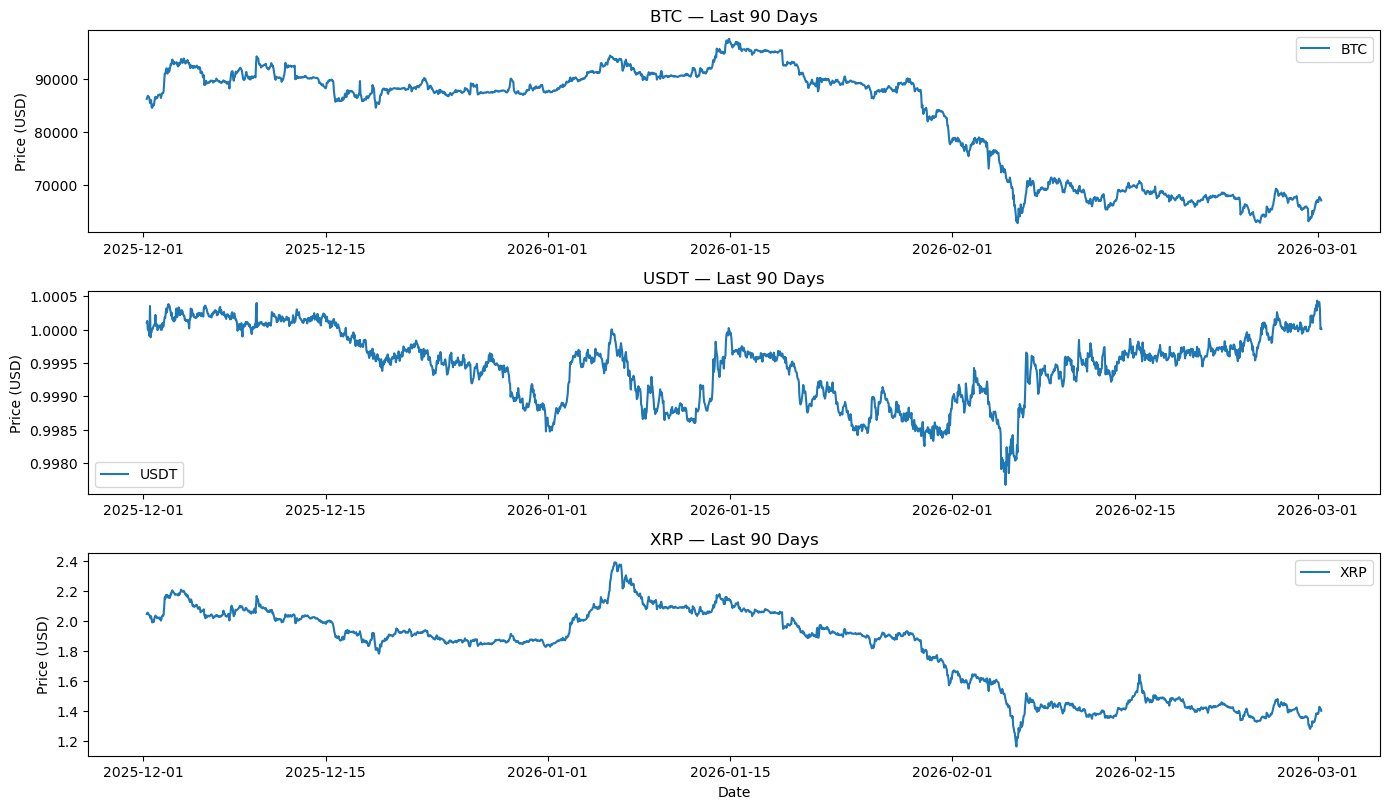

[2026-03-01 15:31:15] === 価格そのものに AR を適用 ===
[2026-03-01 15:31:15] Applying AR on PRICE for BTC ...
[2026-03-01 15:31:15] [BTC] price series length=2161, train=1728, test=433
[2026-03-01 15:31:15] [BTC] AR(5) on PRICE  MSE=1.909912e+07, RMSE=4.370253e+03


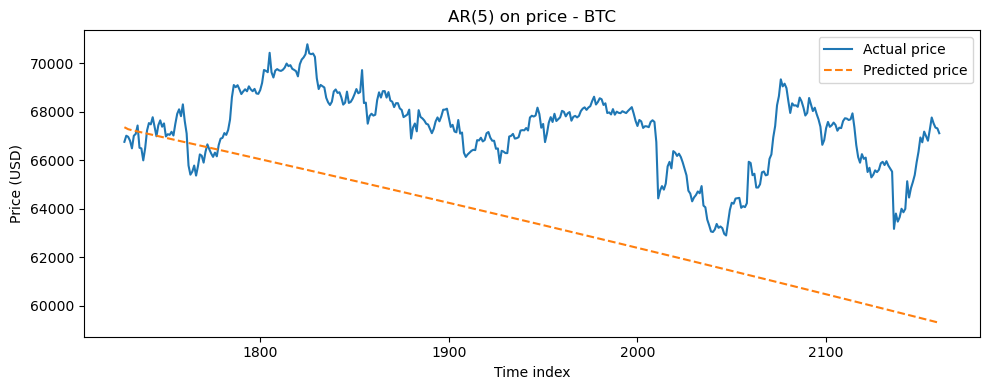

[2026-03-01 15:31:17] Applying AR on PRICE for USDT ...
[2026-03-01 15:31:17] [USDT] price series length=2160, train=1728, test=432
[2026-03-01 15:31:17] [USDT] AR(5) on PRICE  MSE=2.004595e-07, RMSE=4.477271e-04


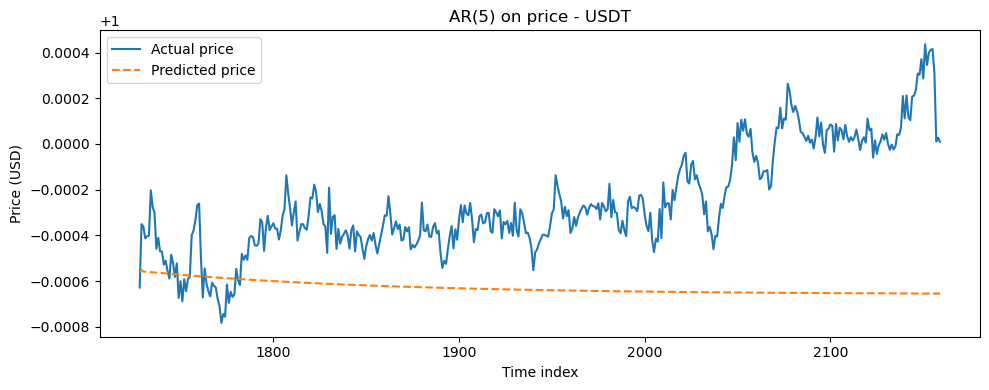

[2026-03-01 15:31:19] Applying AR on PRICE for XRP ...
[2026-03-01 15:31:19] [XRP] price series length=2160, train=1728, test=432
[2026-03-01 15:31:19] [XRP] AR(5) on PRICE  MSE=1.066339e-02, RMSE=1.032637e-01


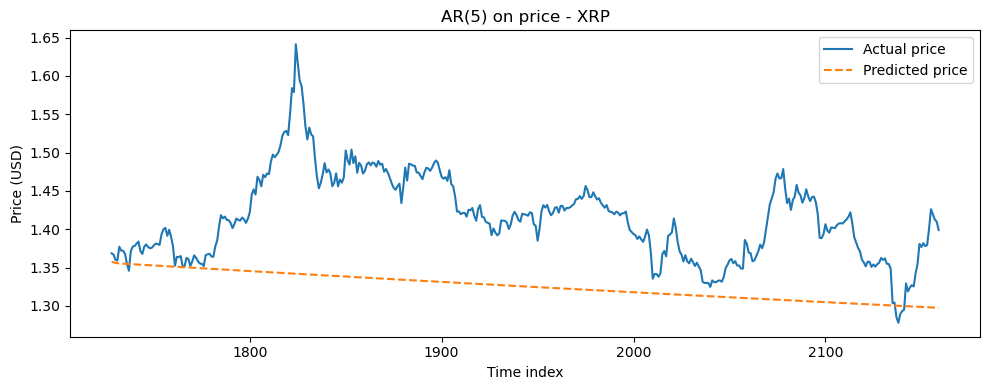

In [1]:
import random
import time
from datetime import datetime

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg


# ------------------------
# 設定
# ------------------------
COINS_POOL = [
    ("bitcoin", "BTC"),
    ("ethereum", "ETH"),
    ("tether", "USDT"),
    ("binancecoin", "BNB"),
    ("solana", "SOL"),
    ("ripple", "XRP"),
    ("usd-coin", "USDC"),
    ("cardano", "ADA"),
    ("dogecoin", "DOGE"),
    ("avalanche-2", "AVAX"),
]

VS = "usd"
DAYS = 90
BASE = "https://api.coingecko.com/api/v3/coins/{id}/market_chart"

session = requests.Session()
session.headers.update({"User-Agent": "Mozilla/5.0"})


def log(msg: str):
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {msg}")


# ------------------------
# データ取得
# ------------------------
def fetch_market_chart(coin_id, days=90, vs="usd"):
    url = BASE.format(id=coin_id)
    params = {"vs_currency": vs, "days": days}

    r = session.get(url, params=params, timeout=30)
    r.raise_for_status()

    data = r.json()
    df = pd.DataFrame(data["prices"], columns=["timestamp", "price"])
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
    df = df.sort_values("timestamp")
    return df


# ------------------------
# 価格そのものに AR を適用
# ------------------------
def apply_ar_price(df: pd.DataFrame, symbol: str, lags: int = 5):
    """
    リターンではなく、価格そのものに AR(lags) を当てる。
    学習: 80% / テスト: 20%
    """
    # インデックスを 0,1,2,... にしておくと predict が楽
    series = pd.Series(df["price"].values.astype(float))  # index = 0..N-1

    n = len(series)
    train_size = int(n * 0.8)
    train = series[:train_size]
    test = series[train_size:]

    log(f"[{symbol}] price series length={n}, train={len(train)}, test={len(test)}")

    model = AutoReg(train, lags=lags, old_names=False)
    res = model.fit()

    # 価格そのものを予測（テスト区間）
    # train のインデックスは 0..train_size-1
    pred = res.predict(start=train_size, end=n - 1)

    mse = ((test.values - pred.values) ** 2).mean()
    rmse = np.sqrt(mse)
    log(f"[{symbol}] AR({lags}) on PRICE  MSE={mse:.6e}, RMSE={rmse:.6e}")

    # プロット（価格の実測 vs 予測）
    plt.figure(figsize=(10, 4))
    # x 軸はテスト区間のインデックスで OK（簡易表示）
    plt.plot(range(train_size, n), test.values, label="Actual price")
    plt.plot(range(train_size, n), pred.values, "--", label="Predicted price")
    plt.title(f"AR({lags}) on price - {symbol}")
    plt.xlabel("Time index")
    plt.ylabel(f"Price ({VS.upper()})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return mse, rmse


# ------------------------
# メイン処理：3選択 → 価格プロット → 価格に AR
# ------------------------
def main():
    log("=== 3銘柄をランダムに選択 ===")

    selected = random.sample(COINS_POOL, 3)
    print("選ばれた3銘柄:")
    for _, sym in selected:
        print(" -", sym)

    # ---------- 価格プロット ----------
    plt.figure(figsize=(14, 8))
    dfs = {}

    for idx, (coin_id, symbol) in enumerate(selected, start=1):
        log(f"Fetching {symbol} ...")
        df = fetch_market_chart(coin_id, DAYS, VS)
        dfs[symbol] = df

        plt.subplot(3, 1, idx)
        plt.plot(df["timestamp"], df["price"], label=symbol)
        plt.title(f"{symbol} — Last {DAYS} Days")
        plt.ylabel(f"Price ({VS.upper()})")
        plt.legend()
        plt.tight_layout()

        time.sleep(0.5)

    plt.xlabel("Date")
    plt.show()

    # ---------- 価格に AR を適用 ----------
    log("=== 価格そのものに AR を適用 ===")

    for symbol, df in dfs.items():
        log(f"Applying AR on PRICE for {symbol} ...")
        apply_ar_price(df, symbol)
        time.sleep(0.5)


if __name__ == "__main__":
    main()